# Typical Usage


In [1]:
from mplchart.chart import Chart
from mplchart.samples import sample_prices
from mplchart.primitives import Candlesticks, Volume, Pane, Line, Area
from mplchart.indicators import SMA, RSI, MACD, DPO

prices = sample_prices()

## SVG charts in notebooks

By default notebooks display charts as PNG images. For sharper inline charts, switch the display format to SVG at the top of your notebook — as this notebook does:

In [2]:
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("svg")

or equivalently with the IPython magic `%config InlineBackend.figure_formats = {"svg"}`. This is notebook display configuration (an IPython/matplotlib feature, not an mplchart one) — it has no effect on scripts or on exporting charts to files.

## Plot chart with indicators

Indicators are evaluated from `prices` during plotting. `SMA` and `MACD` use default rendering. The `@` operator binds `RSI(14)` to a `Line` renderer to customize its display; `Line(RSI(14), ...)` is the equivalent constructor form.

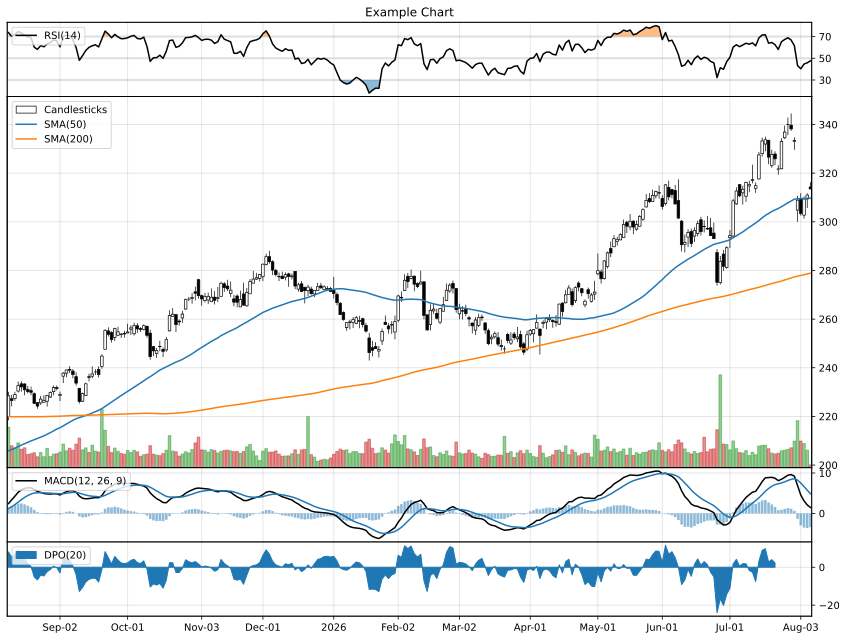

In [3]:
(Chart(prices, title="Example Chart", max_bars=250)
    .plot(
        Candlesticks(), Volume(), SMA(50), SMA(200),
        Pane("above", yticks=(30, 50, 70)),
        RSI(14) @ Line(overbought=70, oversold=30),
        Pane("below"),
        MACD(),
        Pane("below"),
        DPO() @ Area(),
    )
    .show()
)


## Plot existing columns

If your pipeline already computes indicators, store them as columns in `prices` and select them by name. Here pandas calculates the moving average before charting; `plot("sma-20")` reads that column and draws it with default rendering. The column can come from any calculation library. `plot(SMA(20))` also uses default rendering, calculating from `prices` during plotting. Renderer primitives are optional: use `Line("sma-20", color="red")` or `Line(SMA(20), color="red")` when you want to customize the display.

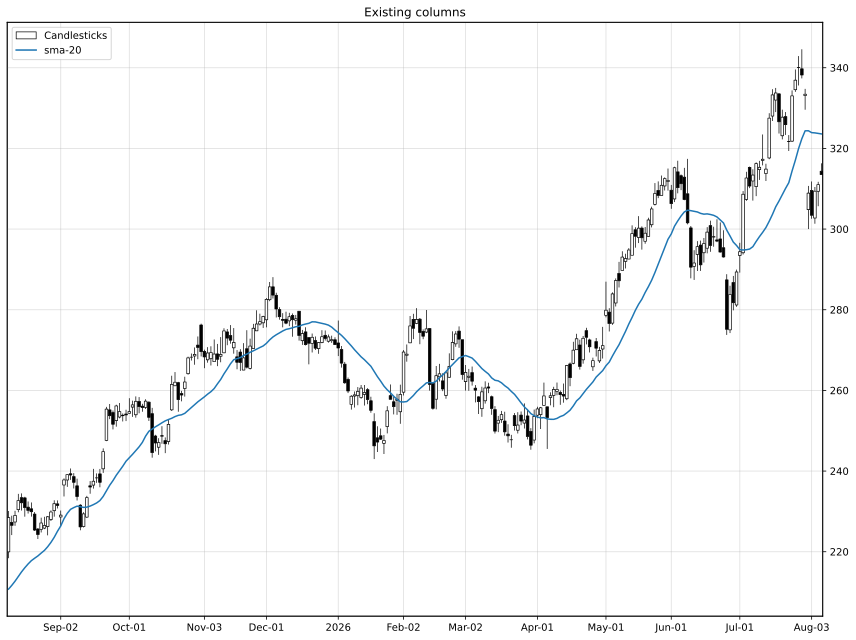

In [4]:
prices["sma-20"] = prices["close"].rolling(20).mean()

Chart(prices, title="Existing columns", max_bars=250).plot(
    Candlesticks(),
    "sma-20",
).show()

## What about polars?

This walkthrough uses pandas data, but mplchart works the same with polars DataFrames — the charting layer is identical, with polars expressions taking the place of indicators. See the *Pandas and polars backends* and *How expressions work* tutorials.